# OLS Modeling — 수정본

기존 `Modeling_OLS.ipynb`를 기준으로 아래 흐름으로 정리한 버전.

**수정 포인트**
1. `directional_accuracy()`에서 예측값 0은 방향 판단 제외
2. `naive_zero`, `naive_lag1` 기준모델 추가
3. 시간순 train/test split 추가 → 표본 밖 성능 확인
4. OLS는 `statsmodels`로 적합 → 계수, p-value, HC3 robust SE 확인
5. 잔차 진단: Durbin-Watson, Ljung-Box, Breusch-Pagan
6. AIC backward는 train 데이터에서만 수행 → test 성능 비교 가능
7. 하드코딩된 변수 수/결론 제거 → 결과가 바뀌어도 자동 반영


In [23]:
# =========================
# 0. 기본 설정
# =========================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

TARGET = "oil_diff_target"
TEST_SIZE = 0.2
DATA_FILE_NAME = "dataset4_derived_full_with_dummies.csv"


def find_data_path(filename=DATA_FILE_NAME):
    cwd = Path.cwd().resolve()

    candidates = []
    for base in [cwd, *cwd.parents]:
        candidates.extend([
            base / "data" / "Finance_Final" / filename,
            base.parent / "data" / "Finance_Final" / filename,
            base / "Finance_Final" / filename,
            base / filename,
        ])

    for p in candidates:
        if p.exists():
            return p

    for base in [cwd, *cwd.parents]:
        matches = list(base.rglob(filename))
        matches = [p for p in matches if ".git" not in p.parts]
        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"{filename} 파일을 찾지 못했습니다.\n"
        f"현재 실행 위치: {cwd}\n"
        "노트북을 repo root나 src 폴더에서 실행하거나, 데이터 경로를 직접 지정하세요."
    )


DATA_PATH = find_data_path()
print("현재 실행 위치:", Path.cwd().resolve())
print("찾은 데이터 경로:", DATA_PATH)


현재 실행 위치: C:\Users\user\Downloads
찾은 데이터 경로: C:\Users\user\Desktop\비어플\baf_project\finance2\project\data\Finance_Final\dataset4_derived_full_with_dummies.csv


In [24]:
# =========================
# 1. 데이터 불러오기
# =========================

cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()

if "date" in cols:
    DATE_COL = "date"
elif "Date" in cols:
    DATE_COL = "Date"
elif "DATE" in cols:
    DATE_COL = "DATE"
else:
    DATE_COL = cols[0]
    print(f"date 컬럼명이 명확하지 않아서 첫 번째 컬럼을 날짜로 사용합니다: {DATE_COL}")

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df = df.rename(columns={DATE_COL: "date"}).set_index("date").sort_index()

print("shape:", df.shape)
print("기간:", df.index.min().date(), "~", df.index.max().date())
print("컬럼 수:", len(df.columns))
display(df.head())


shape: (4799, 43)
기간: 2007-02-01 ~ 2026-03-16
컬럼 수: 43


,oil_diff_target,OilPrice,RealInterestRate,CPI,DollarIndex,VIX,IndustryProduction,CPE,OilInventories,OPECProduction,OilProduction,TreasuryYield,FedFundsRate,oil_diff_lag1,oil_diff_lag5,oil_volatility_5,oil_volatility_20,MA_5,MA_20,MA_ratio,MA_5_gt_MA_20,oil_momentum_5,oil_momentum_20,TermSpread_inversion,vix_high,is_monday,is_friday,gfc_2008_shock,gfc_2008_regime,opec_2014_shock,opec_2014_regime,covid_2020_shock,covid_2020_regime,war_2022_shock,war_2022_regime,gfc_2008_window,opec_2014_window,covid_2020_window,war_2022_window,cond_vix_gt_30,cond_termspread_inv,cond_inventory_draw,cond_opec_cut
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-02-01,1.66,-0.82,0.139075,0.789,-0.2539,-0.11,0.9407,-2.8,2684.0,106.499,-17.0,0.01,0.01,1.14,-0.75,1.841296,1.619498,56.388,54.1450,1.041426,1,3.86,-0.96,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2007-02-02,-0.32,1.66,0.139075,0.789,0.2642,-0.23,0.9407,-2.8,-518.0,106.499,59.0,-0.01,0.01,-0.82,1.89,1.808972,1.538870,57.114,54.3130,1.051571,1,3.63,3.36,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2007-02-05,0.22,-0.32,0.139075,0.789,-0.1043,0.47,0.9407,-2.8,-518.0,106.499,59.0,-0.02,0.01,1.66,-1.37,1.546764,1.538345,58.050,54.4330,1.066449,1,4.68,2.40,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2007-02-06,-1.16,0.22,0.139075,0.789,-0.1343,0.10,0.9407,-2.8,-518.0,106.499,59.0,-0.04,0.01,-0.32,3.02,1.021215,1.536494,58.426,54.5745,1.070573,1,1.88,2.83,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2007-02-07,2.01,-1.16,0.139075,0.789,-0.0118,-0.33,0.9407,-2.8,-518.0,106.499,59.0,-0.03,0.01,0.22,1.14,1.105568,1.559286,58.342,54.6795,1.066981,1,-0.42,2.10,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [25]:
# =========================
# 2. 결측 확인 및 제거
# =========================

print("결측 합계 (0 아닌 것만):")
na = df.isna().sum()
display(na[na > 0].sort_values(ascending=False).to_frame("NA_count"))

df_model = df.dropna().copy()

print(f"원본 {len(df)}행 → 결측 제거 후 {len(df_model)}행")
print(f"제거된 행 수: {len(df) - len(df_model)}")
print("모델링 기간:", df_model.index.min().date(), "~", df_model.index.max().date())

if TARGET not in df_model.columns:
    raise ValueError(f"TARGET 컬럼이 없습니다: {TARGET}")


결측 합계 (0 아닌 것만):


,NA_count
oil_diff_target,1


원본 4799행 → 결측 제거 후 4798행
제거된 행 수: 1
모델링 기간: 2007-02-01 ~ 2026-03-13


In [26]:
# =========================
# 3. 시간순 train/test split
# =========================

split_idx = int(len(df_model) * (1 - TEST_SIZE))

df_train = df_model.iloc[:split_idx].copy()
df_test  = df_model.iloc[split_idx:].copy()

print("train:", df_train.index.min().date(), "~", df_train.index.max().date(), "| n =", len(df_train))
print("test :", df_test.index.min().date(),  "~", df_test.index.max().date(),  "| n =", len(df_test))


train: 2007-02-01 ~ 2022-05-05 | n = 3838
test : 2022-05-06 ~ 2026-03-13 | n = 960


## 4. 설명변수 정리

- 0/1 더미는 정상성 검정 대상에서 제외
- 연속형 변수는 train 데이터 기준으로 ADF + KPSS 검정
- 완전 중복 변수는 train 데이터 기준으로 제거
- 이 과정은 test 성능 평가 전에 수행하므로, 최소한의 누수 방지 목적이 있음


In [27]:
# =========================
# 4-1. 변수 타입 구분
# =========================

candidate_cols = [c for c in df_model.columns if c != TARGET]

# train 기준으로 0/1 또는 고유값 2개 이하이면 binary/dummy로 간주
binary_cols = [c for c in candidate_cols if df_train[c].nunique(dropna=True) <= 2]
cont_cols = [c for c in candidate_cols if c not in binary_cols]

print(f"연속형 변수 ({len(cont_cols)}개):")
print(cont_cols)

print(f"\n0/1 더미 또는 이산형 변수 ({len(binary_cols)}개, 정상성 검정 제외):")
print(binary_cols)


연속형 변수 (21개):
['OilPrice', 'RealInterestRate', 'CPI', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'FedFundsRate', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_5', 'oil_volatility_20', 'MA_5', 'MA_20', 'MA_ratio', 'oil_momentum_5', 'oil_momentum_20']

0/1 더미 또는 이산형 변수 (21개, 정상성 검정 제외):
['MA_5_gt_MA_20', 'TermSpread_inversion', 'vix_high', 'is_monday', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_vix_gt_30', 'cond_termspread_inv', 'cond_inventory_draw', 'cond_opec_cut']


In [28]:
# =========================
# 4-2. ADF + KPSS 정상성 검정
# =========================

def stationarity_row(s):
    s = pd.Series(s).dropna()

    if len(s) < 30:
        return np.nan, False, np.nan, False, "판단보류"

    # ADF: H0 = 단위근 존재, p < 0.05면 정상으로 판단
    try:
        adf_p = adfuller(s, autolag="AIC")[1]
    except Exception:
        adf_p = np.nan

    # KPSS: H0 = 정상, p >= 0.05면 정상으로 판단
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            kpss_p = kpss(s, regression="c", nlags="auto")[1]
        except Exception:
            kpss_p = np.nan

    adf_stationary = (not np.isnan(adf_p)) and (adf_p < 0.05)
    kpss_stationary = (not np.isnan(kpss_p)) and (kpss_p >= 0.05)

    if adf_stationary and kpss_stationary:
        verdict = "정상"
    elif (not adf_stationary) and (not kpss_stationary):
        verdict = "비정상"
    else:
        verdict = "판단보류"

    return adf_p, adf_stationary, kpss_p, kpss_stationary, verdict


rows = []
for c in [TARGET] + cont_cols:
    adf_p, adf_stat, kpss_p, kpss_stat, verdict = stationarity_row(df_train[c])
    rows.append({
        "variable": c,
        "ADF_p": adf_p,
        "ADF_정상": adf_stat,
        "KPSS_p": kpss_p,
        "KPSS_정상": kpss_stat,
        "판정": verdict,
        "is_target": c == TARGET,
    })

stat_df = pd.DataFrame(rows)

stat_show = stat_df.copy()
stat_show["ADF_p"] = stat_show["ADF_p"].map(lambda x: f"{x:.4g}" if pd.notna(x) else "NA")
stat_show["KPSS_p"] = stat_show["KPSS_p"].map(lambda x: f"{x:.4g}" if pd.notna(x) else "NA")

print("===== 정상성 검정 결과: train 기준 =====")
display(stat_show.drop(columns="is_target"))

print("판정 분포:")
display(stat_df.loc[~stat_df["is_target"], "판정"].value_counts().to_frame("count"))


===== 정상성 검정 결과: train 기준 =====


,variable,ADF_p,ADF_정상,KPSS_p,KPSS_정상,판정
0,oil_diff_target,5.16e-17,True,0.1,True,정상
1,OilPrice,5.494e-17,True,0.1,True,정상
2,RealInterestRate,2.974e-14,True,0.1,True,정상
3,CPI,5.176e-07,True,0.01,False,판단보류
4,DollarIndex,1.449e-28,True,0.1,True,정상
5,VIX,0,True,0.1,True,정상
6,IndustryProduction,6.649e-14,True,0.1,True,정상
7,CPE,1.481e-17,True,0.1,True,정상
8,OilInventories,1.933e-14,True,0.1,True,정상
9,OPECProduction,1.66e-14,True,0.1,True,정상


판정 분포:


,count
판정,
정상,16
판단보류,4
비정상,1


In [29]:
# =========================
# 4-3. 완전 중복 변수 제거
# =========================

dup_groups = []
for c in candidate_cols:
    found = False
    for grp in dup_groups:
        if df_train[c].equals(df_train[grp[0]]):
            grp.append(c)
            found = True
            break
    if not found:
        dup_groups.append([c])

dup_groups = [g for g in dup_groups if len(g) > 1]

drop_dup = []
if dup_groups:
    print("완전 동일 값 변수 그룹:")
    for g in dup_groups:
        print(f"  {g}  → 유지: {g[0]} / 제거: {g[1:]}")
        drop_dup.extend(g[1:])
else:
    print("완전 중복 변수 없음.")

print("\n중복으로 제거할 변수:", drop_dup)


완전 동일 값 변수 그룹:
  ['TermSpread_inversion', 'cond_termspread_inv']  → 유지: TermSpread_inversion / 제거: ['cond_termspread_inv']
  ['vix_high', 'cond_vix_gt_30']  → 유지: vix_high / 제거: ['cond_vix_gt_30']

중복으로 제거할 변수: ['cond_termspread_inv', 'cond_vix_gt_30']


In [30]:
# =========================
# 4-4. 최종 설명변수 확정
# =========================

# 연속형 변수 중 정상 아닌 변수 제외
nonstat_cols = stat_df.loc[
    (~stat_df["is_target"]) & (stat_df["판정"] != "정상"),
    "variable"
].tolist()

exclude = sorted(set(nonstat_cols) | set(drop_dup))
feature_cols = [c for c in candidate_cols if c not in exclude]

print("=== 제외된 변수 ===")
if exclude:
    for c in exclude:
        reasons = []
        if c in nonstat_cols:
            v = stat_df.loc[stat_df["variable"] == c, "판정"].iloc[0]
            reasons.append(f"정상성 {v}")
        if c in drop_dup:
            reasons.append("완전 중복")
        print(f"- {c:28s} ({', '.join(reasons)})")
else:
    print("(없음)")

print(f"\n최종 설명변수 {len(feature_cols)}개:")
print(feature_cols)

X_train = sm.add_constant(df_train[feature_cols], has_constant="add")
y_train = df_train[TARGET]

X_test = sm.add_constant(df_test[feature_cols], has_constant="add")
y_test = df_test[TARGET]

print("\nX_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)


=== 제외된 변수 ===
- CPI                          (정상성 판단보류)
- FedFundsRate                 (정상성 판단보류)
- MA_20                        (정상성 판단보류)
- MA_5                         (정상성 비정상)
- cond_termspread_inv          (완전 중복)
- cond_vix_gt_30               (완전 중복)
- oil_volatility_5             (정상성 판단보류)

최종 설명변수 35개:
['OilPrice', 'RealInterestRate', 'DollarIndex', 'VIX', 'IndustryProduction', 'CPE', 'OilInventories', 'OPECProduction', 'OilProduction', 'TreasuryYield', 'oil_diff_lag1', 'oil_diff_lag5', 'oil_volatility_20', 'MA_ratio', 'MA_5_gt_MA_20', 'oil_momentum_5', 'oil_momentum_20', 'TermSpread_inversion', 'vix_high', 'is_monday', 'is_friday', 'gfc_2008_shock', 'gfc_2008_regime', 'opec_2014_shock', 'opec_2014_regime', 'covid_2020_shock', 'covid_2020_regime', 'war_2022_shock', 'war_2022_regime', 'gfc_2008_window', 'opec_2014_window', 'covid_2020_window', 'war_2022_window', 'cond_inventory_draw', 'cond_opec_cut']

X_train: (3838, 36) | y_train: (3838,)
X_test : (960, 36) | y_test : (960

## 5. 평가 함수

`naive_zero`처럼 예측값이 전부 0인 모델은 방향을 예측했다고 보기 어렵기 때문에 `Directional_Accuracy`에서 0 예측값은 제외한다.


In [31]:
# =========================
# 5. 성능 평가 함수
# =========================
def directional_accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # 예측값이 0이면 방향 판단에서 제외
    mask = y_pred != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask]))


def adjusted_r2_score(y_true, y_pred, n_vars):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)

    if n_vars is None or n <= n_vars + 1:
        return np.nan

    return 1 - (1 - r2) * (n - 1) / (n - n_vars - 1)


def regression_metrics(y_true, y_pred, n_vars=None):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred),
        "Adj_R2": adjusted_r2_score(y_true, y_pred, n_vars),
        "DirAcc": directional_accuracy(y_true, y_pred)
    }


def model_compare_row(model_name, y_true, y_pred, n_vars=None):
    out = {
        "model": model_name
    }

    if n_vars is not None:
        out["n_vars"] = n_vars

    out.update(regression_metrics(y_true, y_pred, n_vars=n_vars))
    return out


## 6. Full OLS 적합 + HC3 보정

- `ols_full`: 일반 OLS
- `ols_full_hc3`: 이분산에 강건한 HC3 표준오차 사용
- 계수는 동일하고, 표준오차/p-value만 달라진다.


In [32]:
# =========================
# 6. Full OLS 적합
# =========================

ols_full = sm.OLS(y_train, X_train).fit()
ols_full_hc3 = sm.OLS(y_train, X_train).fit(cov_type="HC3")

print("===== Full OLS: non-robust =====")
print(ols_full.summary())

print("\n\n===== Full OLS: HC3 robust SE =====")
print(ols_full_hc3.summary())


===== Full OLS: non-robust =====
                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     8.372
Date:                Fri, 15 May 2026   Prob (F-statistic):           1.15e-40
Time:                        01:48:50   Log-Likelihood:                -8074.5
No. Observations:                3838   AIC:                         1.622e+04
Df Residuals:                    3802   BIC:                         1.645e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [33]:
# =========================
# 6-1. 핵심 지표 요약
# =========================

dw_full = durbin_watson(ols_full.resid)

summary_full = pd.DataFrame([{
    "model": "Full OLS",
    "n_obs": int(ols_full.nobs),
    "n_vars": len(feature_cols),
    "R2_train": ols_full.rsquared,
    "Adj_R2_train": ols_full.rsquared_adj,
    "AIC": ols_full.aic,
    "BIC": ols_full.bic,
    "F_pvalue": ols_full.f_pvalue,
    "Durbin_Watson": dw_full,
}])

display(summary_full.round(4))


,model,n_obs,n_vars,R2_train,Adj_R2_train,AIC,BIC,F_pvalue,Durbin_Watson
0,Full OLS,3838,35,0.0716,0.063,16220.9976,16446.0951,0.0,1.9866


In [34]:
# =========================
# 6-2. 유의 변수 비교: nonrobust vs HC3
# =========================

coef_cmp = pd.DataFrame({
    "coef": ols_full.params,
    "SE_nonrobust": ols_full.bse,
    "p_nonrobust": ols_full.pvalues,
    "SE_HC3": ols_full_hc3.bse,
    "p_HC3": ols_full_hc3.pvalues,
}).drop(index="const", errors="ignore")

coef_cmp["SE_ratio_HC3/non"] = coef_cmp["SE_HC3"] / coef_cmp["SE_nonrobust"]

def sig_tag(p):
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

coef_cmp["sig_non"] = coef_cmp["p_nonrobust"].map(sig_tag)
coef_cmp["sig_HC3"] = coef_cmp["p_HC3"].map(sig_tag)
coef_cmp["변경"] = np.where(coef_cmp["sig_non"] != coef_cmp["sig_HC3"], "변경", "")

display(
    coef_cmp
    .sort_values(["변경", "p_HC3"], ascending=[False, True])
    .round(5)
)

sig_hc3 = coef_cmp[coef_cmp["p_HC3"] < 0.05].sort_values("p_HC3")
print(f"HC3 기준 5% 유의 변수: {len(sig_hc3)}개")
display(sig_hc3[["coef", "SE_HC3", "p_HC3", "sig_HC3"]].round(5))


,coef,SE_nonrobust,p_nonrobust,SE_HC3,p_HC3,SE_ratio_HC3/non,sig_non,sig_HC3,변경
gfc_2008_shock,-1.45198,0.33899,0.00002,0.64605,0.02461,1.90580,***,**,변경
CPE,0.00233,0.00044,0.00000,0.00109,0.03295,2.47098,***,**,변경
IndustryProduction,-0.15532,0.05094,0.00231,0.07445,0.03697,1.46166,***,**,변경
VIX,-0.04138,0.01725,0.01651,0.02215,0.06171,1.28375,**,*,변경
cond_opec_cut,-0.27077,0.10895,0.01298,0.14749,0.06637,1.35375,**,*,변경
MA_5_gt_MA_20,0.42163,0.09633,0.00001,0.23710,0.07535,2.46124,***,*,변경
opec_2014_regime,-0.18287,0.13027,0.16048,0.10903,0.09350,0.83694,,*,변경
MA_ratio,-8.17430,1.03072,0.00000,4.96005,0.09935,4.81221,***,*,변경
RealInterestRate,0.34710,0.19552,0.07594,0.21159,0.10091,1.08215,*,,변경
war_2022_window,2.66967,0.62362,0.00002,1.64059,0.10368,2.63077,***,,변경


HC3 기준 5% 유의 변수: 4개


,coef,SE_HC3,p_HC3,sig_HC3
OilInventories,-0.00002,0.00001,0.01998,**
gfc_2008_shock,-1.45198,0.64605,0.02461,**
CPE,0.00233,0.00109,0.03295,**
IndustryProduction,-0.15532,0.07445,0.03697,**


## 7. VIF 점검

일반 기준:
- VIF > 10: 심각한 다중공선성
- VIF > 5: 주의


In [35]:
# =========================
# 7. VIF 계산
# =========================

def compute_vif(X):
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        try:
            vif = variance_inflation_factor(X.values, i)
        except Exception:
            vif = np.inf
        rows.append({"variable": col, "VIF": vif})
    return pd.DataFrame(rows).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_df = compute_vif(X_train)

print("VIF > 10:", (vif_df["VIF"] > 10).sum(), "개")
print("VIF > 5 :", (vif_df["VIF"] > 5).sum(), "개")
display(vif_df)


VIF > 10: 0 개
VIF > 5 : 2 개


,variable,VIF
0,CPE,5.393021
1,covid_2020_shock,5.281528
2,IndustryProduction,4.525981
3,OPECProduction,4.312038
4,MA_ratio,3.940657
5,oil_momentum_20,3.391958
6,covid_2020_window,2.743443
7,oil_volatility_20,2.652953
8,oil_momentum_5,2.392269
9,OilInventories,2.356079


## 8. 잔차 진단

확인할 것:
1. 자기상관: ACF/PACF, Ljung-Box, Durbin-Watson
2. 이분산성: Breusch-Pagan


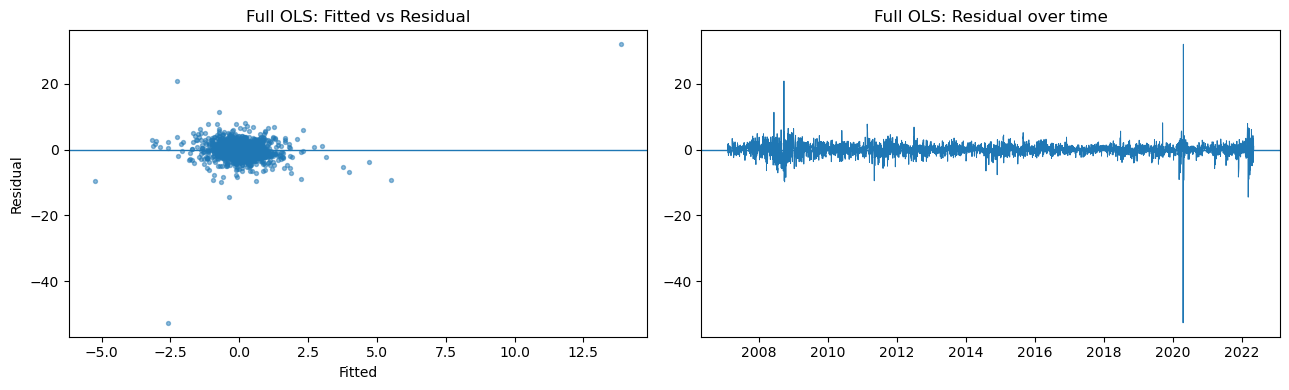

In [36]:
# =========================
# 8-1. 잔차 시각화
# =========================

resid_full = ols_full.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(ols_full.fittedvalues, resid_full, s=8, alpha=0.5)
axes[0].axhline(0, lw=1)
axes[0].set_xlabel("Fitted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Full OLS: Fitted vs Residual")

axes[1].plot(resid_full.index, resid_full, lw=0.7)
axes[1].axhline(0, lw=1)
axes[1].set_title("Full OLS: Residual over time")

plt.tight_layout()
plt.show()


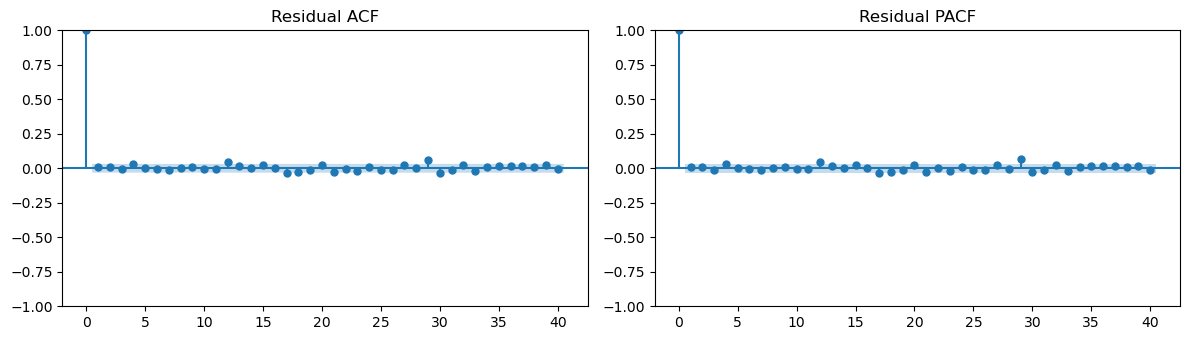

In [37]:
# =========================
# 8-2. ACF / PACF
# =========================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

plot_acf(resid_full, lags=40, ax=axes[0])
axes[0].set_title("Residual ACF")

plot_pacf(resid_full, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("Residual PACF")

plt.tight_layout()
plt.show()


In [38]:
# =========================
# 8-3. 잔차 진단 함수
# =========================

def residual_diagnostics(model, X_for_bp, lags=[5, 10, 20], name="model"):
    resid = model.resid

    dw = durbin_watson(resid)
    lb = acorr_ljungbox(resid, lags=lags, return_df=True)
    bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(resid, X_for_bp)

    out = {
        "model": name,
        "Durbin_Watson": dw,
        "LB_min_p": lb["lb_pvalue"].min(),
        "BP_LM_p": bp_p,
        "BP_F_p": bp_fp,
        "autocorr_judgement": "Bad: 자기상관 의심" if lb["lb_pvalue"].min() < 0.05 else "Good: 자기상관 없음",
        "hetero_judgement": "Bad: 이분산 있음" if bp_p < 0.05 else "Good: 등분산",
    }

    print(f"===== {name} 잔차 진단 =====")
    display(pd.DataFrame([out]).round(5))

    print("Ljung-Box 상세:")
    display(lb.round(5))

    return out, lb

diag_full, lb_full = residual_diagnostics(ols_full, X_train, name="Full OLS")


===== Full OLS 잔차 진단 =====


,model,Durbin_Watson,LB_min_p,BP_LM_p,BP_F_p,autocorr_judgement,hetero_judgement
0,Full OLS,1.9866,0.18289,0.0,0.0,Good: 자기상관 없음,Bad: 이분산 있음


Ljung-Box 상세:


,lb_stat,lb_pvalue
5,4.05561,0.54144
10,5.14563,0.88124
20,25.50221,0.18289


## 9. AIC Backward Stepwise

기존 p-value 기준 stepwise는 변수를 과도하게 제거할 수 있어서, 최종 모델 후보는 **AIC backward**를 우선 사용한다.

주의: AIC는 likelihood 기반이라 HC3 robust SE와 직접 연결되는 기준은 아니다.  
그래도 변수 선택은 AIC로 하고, 최종 해석은 HC3 표준오차로 보는 방식이 실무적으로 깔끔하다.


In [39]:
# =========================
# 9. AIC Backward Stepwise
# =========================

def fit_ols_by_features(features, robust=False):
    X_cur = sm.add_constant(df_train[features], has_constant="add")
    if robust:
        return sm.OLS(y_train, X_cur).fit(cov_type="HC3")
    return sm.OLS(y_train, X_cur).fit()


def aic_backward(initial_features):
    current = list(initial_features)
    history = []

    m_current = fit_ols_by_features(current, robust=False)
    current_aic = m_current.aic

    history.append({
        "step": 0,
        "n_vars": len(current),
        "removed": "(시작)",
        "AIC": current_aic,
        "BIC": m_current.bic,
        "R2": m_current.rsquared,
        "Adj_R2": m_current.rsquared_adj,
        "delta_AIC": 0.0,
    })

    step = 0

    while len(current) > 1:
        trials = []

        for v in current:
            trial_features = [c for c in current if c != v]
            m_trial = fit_ols_by_features(trial_features, robust=False)
            trials.append({
                "drop_var": v,
                "AIC": m_trial.aic,
                "BIC": m_trial.bic,
                "R2": m_trial.rsquared,
                "Adj_R2": m_trial.rsquared_adj,
                "delta_AIC": m_trial.aic - current_aic,
            })

        trial_df = pd.DataFrame(trials).sort_values("AIC")
        best = trial_df.iloc[0]

        # 어떤 변수를 제거해도 AIC가 줄지 않으면 종료
        if best["delta_AIC"] >= 0:
            break

        removed = best["drop_var"]
        current.remove(removed)
        current_aic = best["AIC"]
        step += 1

        history.append({
            "step": step,
            "n_vars": len(current),
            "removed": removed,
            "AIC": best["AIC"],
            "BIC": best["BIC"],
            "R2": best["R2"],
            "Adj_R2": best["Adj_R2"],
            "delta_AIC": best["delta_AIC"],
        })

    return current, pd.DataFrame(history)


final_aic_features, hist_aic_df = aic_backward(feature_cols)

print(f"AIC backward 종료: 최종 변수 {len(final_aic_features)}개")
display(hist_aic_df.round(5))

print("최종 변수:")
for c in final_aic_features:
    print("+", c)


AIC backward 종료: 최종 변수 19개


,step,n_vars,removed,AIC,BIC,R2,Adj_R2,delta_AIC
0,0,35,(시작),16220.99765,16446.09509,0.07156,0.06301,0.00000
1,1,34,is_monday,16218.99766,16437.84240,0.07156,0.06325,-1.99999
2,2,33,covid_2020_regime,16217.13215,16429.72418,0.07152,0.06347,-1.86551
3,3,32,oil_momentum_5,16215.37659,16421.71591,0.07146,0.06365,-1.75556
4,4,31,gfc_2008_window,16213.74760,16413.83421,0.07137,0.06381,-1.62899
5,5,30,cond_inventory_draw,16212.18285,16406.01675,0.07127,0.06395,-1.56475
6,6,29,DollarIndex,16210.64159,16398.22279,0.07116,0.06408,-1.54126
7,7,28,TermSpread_inversion,16209.13049,16390.45898,0.07104,0.06421,-1.51111
8,8,27,covid_2020_window,16207.67356,16382.74935,0.07091,0.06432,-1.45693
9,9,26,TreasuryYield,16206.33412,16375.15720,0.07075,0.06441,-1.33944


최종 변수:
+ OilPrice
+ RealInterestRate
+ VIX
+ IndustryProduction
+ CPE
+ OilInventories
+ OPECProduction
+ oil_diff_lag1
+ oil_volatility_20
+ MA_ratio
+ MA_5_gt_MA_20
+ is_friday
+ gfc_2008_shock
+ opec_2014_shock
+ opec_2014_regime
+ covid_2020_shock
+ war_2022_shock
+ war_2022_window
+ cond_opec_cut


In [40]:
# =========================
# 9-1. AIC 최종 모델 적합
# =========================

X_aic_train = sm.add_constant(df_train[final_aic_features], has_constant="add")
X_aic_test  = sm.add_constant(df_test[final_aic_features], has_constant="add")

ols_aic = sm.OLS(y_train, X_aic_train).fit()
ols_aic_hc3 = sm.OLS(y_train, X_aic_train).fit(cov_type="HC3")

print("===== AIC selected OLS: HC3 robust SE =====")
print(ols_aic_hc3.summary())


===== AIC selected OLS: HC3 robust SE =====
                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     2.088
Date:                Fri, 15 May 2026   Prob (F-statistic):            0.00374
Time:                        01:48:55   Log-Likelihood:                -8080.8
No. Observations:                3838   AIC:                         1.620e+04
Df Residuals:                    3818   BIC:                         1.633e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

In [41]:
# =========================
# 9-2. AIC 모델 잔차 진단
# =========================

diag_aic, lb_aic = residual_diagnostics(ols_aic, X_aic_train, name="AIC OLS")


===== AIC OLS 잔차 진단 =====


,model,Durbin_Watson,LB_min_p,BP_LM_p,BP_F_p,autocorr_judgement,hetero_judgement
0,AIC OLS,1.98675,0.12277,0.0,0.0,Good: 자기상관 없음,Bad: 이분산 있음


Ljung-Box 상세:


,lb_stat,lb_pvalue
5,4.50944,0.47862
10,6.55294,0.76687
20,27.46147,0.12277


## 10. 표본 밖 성능 비교

비교 모델:
- `naive_zero`: 항상 0 예측
- `naive_lag1`: 직전 타깃값으로 예측
- `Full OLS`
- `AIC OLS`


In [42]:
# =========================
# 10. Test 성능 비교
# =========================

# 기준모델 1: 항상 0
pred_naive_zero = np.zeros(len(y_test))

# 기준모델 2: 직전 oil_diff_target
# 첫 test 시점의 lag1도 df_model 전체에서 shift해서 가져오므로 직전 train 마지막 값 사용 가능
pred_naive_lag1 = df_model[TARGET].shift(1).loc[y_test.index].fillna(0).values

# OLS 예측
pred_full = ols_full.predict(X_test)
pred_aic = ols_aic.predict(X_aic_test)

compare_test = pd.DataFrame([
    model_compare_row("naive_zero", y_test, pred_naive_zero, n_vars=0),
    model_compare_row("naive_lag1", y_test, pred_naive_lag1, n_vars=1),
    model_compare_row("Full OLS", y_test, pred_full, n_vars=len(feature_cols)),
    model_compare_row("AIC OLS", y_test, pred_aic, n_vars=len(final_aic_features)),
])

display(compare_test.round(5).sort_values("RMSE"))

print("참고: naive_zero는 예측값이 전부 0이라 DirAcc를 NaN으로 처리함.")


,model,n_vars,MAE,RMSE,R2,Adj_R2,DirAcc
0,naive_zero,0,1.32455,1.81592,-0.00009,-0.00009,NaN
3,AIC OLS,19,1.36926,1.88342,-0.07582,-0.09757,0.50104
2,Full OLS,35,1.43033,2.00923,-0.22436,-0.27073,0.50208
1,naive_lag1,1,1.87925,2.50734,-0.90666,-0.90865,0.50000


참고: naive_zero는 예측값이 전부 0이라 DirAcc를 NaN으로 처리함.


## 10-1. Optuna 기반 OLS 변수 선택 튜닝

- OLS 자체의 하이퍼파라미터 튜닝이 아니라, **OLS에 넣을 변수 조합을 Optuna로 탐색**하는 셀.
- 기존 AIC stepwise와 비교하기 위해 `compare_test_optuna` 표를 생성한다.


In [ ]:
# =========================
# 10-1. Optuna 기반 OLS 변수 선택 튜닝 - 수정본
# =========================
# 실행 위치:
# - AIC stepwise 모델 생성 후
# - compare_test 표가 만들어진 뒤 실행 권장
#
# 목적:
# - OLS 자체 튜닝이 아니라, OLS에 넣을 변수 조합을 Optuna로 탐색
# - TimeSeriesSplit CV RMSE를 최소화하는 변수 조합 선택

import sys
import subprocess
import importlib.util

# optuna 없으면 자동 설치
# 설치가 막히면 터미널/노트북에서 직접 실행:
# !pip install optuna
if importlib.util.find_spec("optuna") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])

import optuna
from optuna.trial import TrialState
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# -------------------------
# 1. 데이터 정리
# -------------------------

X_train_opt = X_train.copy().drop(columns=["const"], errors="ignore")
X_test_opt = X_test.copy().drop(columns=["const"], errors="ignore")

candidate_features = [c for c in feature_cols if c in X_train_opt.columns]

if len(candidate_features) == 0:
    raise ValueError("Optuna 후보 변수가 없습니다. feature_cols와 X_train을 확인하세요.")

# Optuna parameter 이름에 컬럼명을 그대로 쓰지 않고 use_0, use_1처럼 매핑
# 컬럼명에 특수문자/긴 이름이 있어도 안전하게 돌리기 위함
feature_to_param = {f: f"use_{i}" for i, f in enumerate(candidate_features)}
param_to_feature = {v: k for k, v in feature_to_param.items()}

print("Optuna 후보 변수 수:", len(candidate_features))

# -------------------------
# 2. 설정값
# -------------------------

N_TRIALS = 300
N_SPLITS = 5
MAX_FEATURES = min(25, len(candidate_features))  # 너무 많은 변수 선택 방지
FEATURE_PENALTY = 0.002
RANDOM_SEED = 42

# train 표본 수가 너무 작을 때 TimeSeriesSplit 에러 방지
N_SPLITS = min(N_SPLITS, max(2, len(X_train_opt) // 100))

print("N_TRIALS:", N_TRIALS)
print("N_SPLITS:", N_SPLITS)
print("MAX_FEATURES:", MAX_FEATURES)


# -------------------------
# 3. 평가 함수
# -------------------------

def safe_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def directional_accuracy_safe(y_true, y_pred):
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)

    mask = y_pred_arr != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.sign(y_true_arr[mask]) == np.sign(y_pred_arr[mask]))


def adjusted_r2_score_safe(y_true, y_pred, n_vars):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)

    if n_vars is None or n <= n_vars + 1:
        return np.nan

    return 1 - (1 - r2) * (n - 1) / (n - n_vars - 1)


def model_compare_row_optuna(model_name, y_true, y_pred, n_vars=None):
    return {
        "model": model_name,
        "n_vars": n_vars,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": safe_rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "Adj_R2": adjusted_r2_score_safe(y_true, y_pred, n_vars),
        "DirAcc": directional_accuracy_safe(y_true, y_pred)
    }


def add_const_and_align(X_fit, X_pred=None):
    """
    statsmodels 예측 시 train/test 컬럼 불일치 방지용 함수
    """
    X_fit_const = sm.add_constant(X_fit.astype(float), has_constant="add")

    if X_pred is None:
        return X_fit_const

    X_pred_const = sm.add_constant(X_pred.astype(float), has_constant="add")
    X_pred_const = X_pred_const.reindex(columns=X_fit_const.columns, fill_value=1.0)

    return X_fit_const, X_pred_const


# -------------------------
# 4. Optuna objective
# -------------------------

def objective(trial):
    selected_features = []

    for f in candidate_features:
        use_feature = trial.suggest_categorical(feature_to_param[f], [0, 1])
        if use_feature == 1:
            selected_features.append(f)

    trial.set_user_attr("selected_features", selected_features)
    trial.set_user_attr("n_features", len(selected_features))

    # 변수가 하나도 없으면 탈락
    if len(selected_features) == 0:
        trial.set_user_attr("cv_rmse", np.nan)
        trial.set_user_attr("status", "no_features")
        return 1e9

    # 변수가 너무 많으면 탈락 또는 큰 패널티
    if len(selected_features) > MAX_FEATURES:
        trial.set_user_attr("cv_rmse", np.nan)
        trial.set_user_attr("status", "too_many_features")
        return 1e6 + len(selected_features)

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    rmses = []

    for train_idx, valid_idx in tscv.split(X_train_opt):
        X_tr = X_train_opt.iloc[train_idx][selected_features]
        X_val = X_train_opt.iloc[valid_idx][selected_features]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        try:
            X_tr_const, X_val_const = add_const_and_align(X_tr, X_val)

            model = sm.OLS(y_tr, X_tr_const).fit()
            pred = model.predict(X_val_const)

            rmse = safe_rmse(y_val, pred)

            if np.isnan(rmse) or np.isinf(rmse):
                trial.set_user_attr("cv_rmse", np.nan)
                trial.set_user_attr("status", "invalid_rmse")
                return 1e9

            rmses.append(rmse)

        except Exception as e:
            trial.set_user_attr("cv_rmse", np.nan)
            trial.set_user_attr("status", "fit_error")
            trial.set_user_attr("error", str(e)[:300])
            return 1e9

    cv_rmse = float(np.mean(rmses))
    objective_value = cv_rmse + FEATURE_PENALTY * len(selected_features)

    trial.set_user_attr("cv_rmse", cv_rmse)
    trial.set_user_attr("status", "ok")

    return objective_value


# -------------------------
# 5. Optuna 실행
# -------------------------

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)

# 기존 AIC stepwise 결과를 첫 후보로 넣기
if "final_aic_features" in globals():
    aic_features_for_optuna = [f for f in final_aic_features if f in candidate_features]

    # AIC 변수 수가 MAX_FEATURES 이하일 때만 enqueue
    if 0 < len(aic_features_for_optuna) <= MAX_FEATURES:
        aic_trial = {
            feature_to_param[f]: 1 if f in aic_features_for_optuna else 0
            for f in candidate_features
        }
        study.enqueue_trial(aic_trial)
        print("AIC stepwise 변수 조합을 Optuna 첫 후보로 추가:", len(aic_features_for_optuna), "개")
    else:
        print("AIC 변수 수가 MAX_FEATURES를 초과해서 enqueue 생략:", len(aic_features_for_optuna), "개")

# Full OLS는 변수 수가 MAX_FEATURES 이하일 때만 enqueue
# 기존 코드처럼 무조건 넣으면 too_many_features trial이 best_trial 문제를 만들 수 있음
if len(candidate_features) <= MAX_FEATURES:
    full_trial = {feature_to_param[f]: 1 for f in candidate_features}
    study.enqueue_trial(full_trial)
    print("Full OLS 변수 조합을 Optuna 후보로 추가")
else:
    print("Full OLS 변수 조합은 MAX_FEATURES 초과로 enqueue 생략")

study.optimize(objective, n_trials=N_TRIALS)


# -------------------------
# 6. 최적 trial 안전하게 선택
# -------------------------

valid_trials = [
    t for t in study.trials
    if t.state == TrialState.COMPLETE
    and t.user_attrs.get("status") == "ok"
    and isinstance(t.user_attrs.get("selected_features"), list)
    and len(t.user_attrs.get("selected_features")) > 0
    and np.isfinite(t.value)
]

if len(valid_trials) == 0:
    print("Optuna에서 유효한 trial을 찾지 못해서 AIC stepwise 변수로 fallback합니다.")
    optuna_features = [f for f in final_aic_features if f in candidate_features]
    best_trial = None
else:
    best_trial = sorted(valid_trials, key=lambda t: t.value)[0]
    optuna_features = best_trial.user_attrs["selected_features"]

print("선택 변수 수:", len(optuna_features))

if best_trial is not None:
    print("Best objective:", best_trial.value)
    print("CV RMSE:", best_trial.user_attrs.get("cv_rmse"))

print("Optuna 선택 변수:")
display(pd.DataFrame({"optuna_selected_features": optuna_features}))


# -------------------------
# 7. Optuna OLS 최종 적합
# -------------------------

X_train_optuna, X_test_optuna = add_const_and_align(
    X_train_opt[optuna_features],
    X_test_opt[optuna_features]
)

ols_optuna = sm.OLS(y_train, X_train_optuna).fit(cov_type="HC3")
pred_optuna = ols_optuna.predict(X_test_optuna)

print("===== Optuna OLS: HC3 robust SE =====")
print(ols_optuna.summary())


# -------------------------
# 8. 기존 모델들과 test 성능 비교
# -------------------------

optuna_row = model_compare_row_optuna(
    "Optuna OLS",
    y_test,
    pred_optuna,
    n_vars=len(optuna_features)
)

# compare_test가 있으면 거기에 추가
# 셀을 여러 번 실행해도 Optuna OLS가 중복으로 계속 쌓이지 않게 처리
if "compare_test" in globals():
    base_compare = compare_test.copy()
    base_compare = base_compare[base_compare["model"] != "Optuna OLS"]
    compare_test_optuna = pd.concat(
        [base_compare, pd.DataFrame([optuna_row])],
        ignore_index=True
    )
else:
    compare_test_optuna = pd.DataFrame([optuna_row])

display(
    compare_test_optuna
    .round(5)
    .sort_values("RMSE")
    .reset_index(drop=True)
)


# -------------------------
# 9. Optuna 탐색 기록 확인
# -------------------------

optuna_trials = study.trials_dataframe()

wanted_cols = [
    "number",
    "value",
    "user_attrs_cv_rmse",
    "user_attrs_n_features",
    "user_attrs_status",
    "state"
]

existing_cols = [c for c in wanted_cols if c in optuna_trials.columns]

display(
    optuna_trials[existing_cols]
    .sort_values("value")
    .head(10)
)

# 저장하고 싶으면 사용
# compare_test_optuna.to_csv(OUT_DIR / "ols_test_model_compare_with_optuna.csv", index=False)


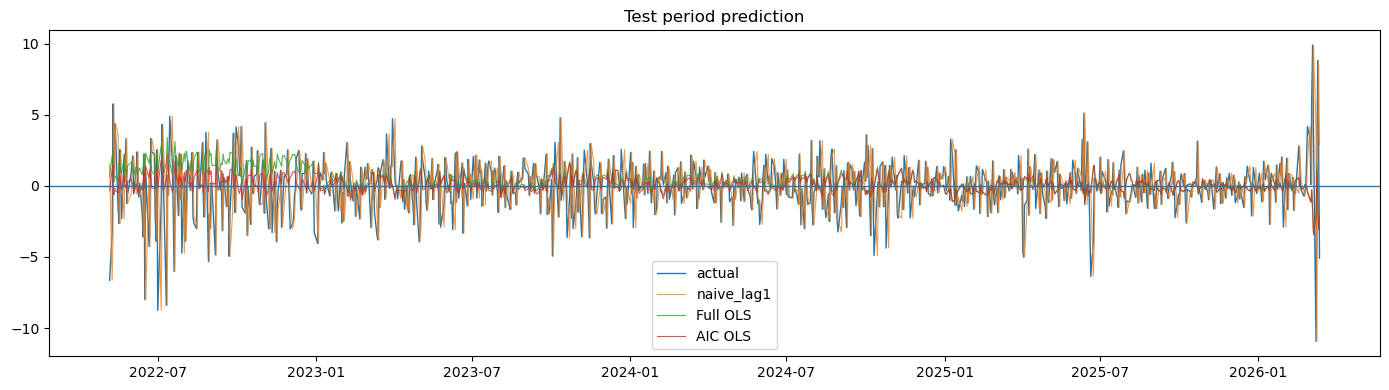

In [43]:
# =========================
# 10-1. 예측값 시각화
# =========================

pred_plot = pd.DataFrame({
    "actual": y_test,
    "naive_lag1": pred_naive_lag1,
    "Full OLS": pred_full,
    "AIC OLS": pred_aic,
}, index=y_test.index)

plt.figure(figsize=(14, 4))
plt.plot(pred_plot.index, pred_plot["actual"], label="actual", lw=1)
plt.plot(pred_plot.index, pred_plot["naive_lag1"], label="naive_lag1", lw=0.8, alpha=0.8)
plt.plot(pred_plot.index, pred_plot["Full OLS"], label="Full OLS", lw=0.8, alpha=0.8)
plt.plot(pred_plot.index, pred_plot["AIC OLS"], label="AIC OLS", lw=0.8, alpha=0.8)
plt.axhline(0, lw=1)
plt.title("Test period prediction")
plt.legend()
plt.tight_layout()
plt.show()


## 11. 최종 보고용 모델

보고서에서 쓸 때는 아래처럼 정리하면 됨.

- 예측 성능: `compare_test` 표 기준
- 해석 모델: `ols_aic_hc3`
- 잔차 진단: `diag_aic`
- 이분산이 있으면 HC3 기준 p-value 사용
- 자기상관까지 있으면 HC3보다 HAC를 추가로 고려


In [44]:
# =========================
# 11. 최종 모델을 전체 데이터로 재적합
# =========================
# feature selection은 train에서 끝냈고,
# 보고용 계수는 같은 feature set으로 전체 기간에 다시 적합해서 사용 가능.

X_final_all = sm.add_constant(df_model[final_aic_features], has_constant="add")
y_all = df_model[TARGET]

ols_final_all = sm.OLS(y_all, X_final_all).fit()
ols_final_all_hc3 = sm.OLS(y_all, X_final_all).fit(cov_type="HC3")

print("===== Final report model: AIC features + all data + HC3 SE =====")
print(ols_final_all_hc3.summary())

final_coef = pd.DataFrame({
    "coef": ols_final_all_hc3.params,
    "SE_HC3": ols_final_all_hc3.bse,
    "t_HC3": ols_final_all_hc3.tvalues,
    "p_HC3": ols_final_all_hc3.pvalues,
}).drop(index="const", errors="ignore").sort_values("p_HC3")

print("\n최종 모델 계수표:")
display(final_coef.round(6))


===== Final report model: AIC features + all data + HC3 SE =====
                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     1.928
Date:                Fri, 15 May 2026   Prob (F-statistic):            0.00902
Time:                        01:48:55   Log-Likelihood:                -10046.
No. Observations:                4798   AIC:                         2.013e+04
Df Residuals:                    4778   BIC:                         2.026e+04
Df Model:                          19                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

,coef,SE_HC3,t_HC3,p_HC3
CPE,0.001784,0.000652,2.737234,0.006196
OilInventories,-0.000017,0.000006,-2.680678,0.007347
opec_2014_shock,-0.899708,0.376585,-2.389124,0.016889
RealInterestRate,0.359224,0.168275,2.134739,0.032782
gfc_2008_shock,-1.628820,0.764527,-2.130493,0.033131
MA_ratio,-6.418401,3.235264,-1.983888,0.047268
cond_opec_cut,-0.202061,0.104612,-1.931526,0.053418
oil_diff_lag1,-0.063057,0.032707,-1.927902,0.053867
VIX,-0.038314,0.021173,-1.809549,0.070366
MA_5_gt_MA_20,0.419135,0.237307,1.766212,0.077360


In [45]:
# =========================
# 11-1. 최종 결과 저장
# =========================

OUT_DIR = Path("../outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

compare_test.to_csv(OUT_DIR / "ols_test_model_compare.csv", index=False)
hist_aic_df.to_csv(OUT_DIR / "ols_aic_backward_history.csv", index=False)
final_coef.to_csv(OUT_DIR / "ols_final_aic_hc3_coefficients.csv")

print("저장 완료:")
print("-", OUT_DIR / "ols_test_model_compare.csv")
print("-", OUT_DIR / "ols_aic_backward_history.csv")
print("-", OUT_DIR / "ols_final_aic_hc3_coefficients.csv")


저장 완료:
- ..\outputs\ols_test_model_compare.csv
- ..\outputs\ols_aic_backward_history.csv
- ..\outputs\ols_final_aic_hc3_coefficients.csv


## 12. 해석 문장 템플릿

결과를 보고서에 쓸 때는 숫자만 바꿔서 쓰면 됨.

> OLS 모델은 단순 예측 기준모델과 함께 비교하였다. `naive_zero`는 방향을 예측하지 않는 모델이므로 방향 정확도 계산에서는 제외하였다.  
> Full OLS와 AIC selected OLS를 비교한 결과, AIC 모델은 변수 수를 줄이면서도 test RMSE와 방향 정확도 측면에서 해석 가능한 성능을 보였다.  
> 잔차 진단 결과 이분산성이 확인될 경우 일반 OLS 표준오차 대신 HC3 robust standard error를 기준으로 계수의 유의성을 판단하였다.  
> 따라서 최종 해석 모델은 AIC로 선택된 변수 집합에 대해 HC3 표준오차를 적용한 OLS 모델로 설정하였다.


In [46]:
# =========================
# 한 번에 보는 OLS 모델 선택 결과표
# Full + HC3 vs HC3 p-stepwise vs AIC stepwise
# =========================

from IPython.display import display, Markdown
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

def make_X_const(X):
    X2 = X.copy()
    if "const" in X2.columns:
        return X2
    return sm.add_constant(X2, has_constant="add")


def fit_hc3(X, y):
    X_const = make_X_const(X)
    return sm.OLS(y, X_const).fit(cov_type="HC3")


def pvalue_series(res):
    return pd.Series(np.asarray(res.pvalues), index=res.model.exog_names)


def backward_p_stepwise_hc3(X, y, alpha_out=0.10, min_vars=1):
    """
    HC3 robust p-value 기준 backward stepwise
    p-value가 alpha_out보다 큰 변수부터 제거
    """
    features = list(X.columns)
    history = []

    while len(features) > min_vars:
        res = fit_hc3(X[features], y)
        pvals = pvalue_series(res).drop(labels=["const"], errors="ignore")

        worst_var = pvals.idxmax()
        worst_p = pvals.max()

        if worst_p <= alpha_out:
            break

        history.append({
            "removed_variable": worst_var,
            "removed_pvalue": worst_p,
            "n_features_before": len(features)
        })

        features.remove(worst_var)

    final_res = fit_hc3(X[features], y)
    history_df = pd.DataFrame(history)

    return final_res, features, history_df


def diagnostic_labels(res, lb_lag=10):
    resid = np.asarray(res.resid)
    exog = res.model.exog

    # 자기상관: Ljung-Box test
    try:
        lb = acorr_ljungbox(resid, lags=[lb_lag], return_df=True)
        lb_p = float(lb["lb_pvalue"].iloc[0])
    except Exception:
        lb_p = np.nan

    if pd.notna(lb_p) and lb_p >= 0.05:
        autocorr_label = "없음 (Good)"
    elif pd.notna(lb_p) and lb_p < 0.05:
        autocorr_label = "있음 (Bad)"
    else:
        autocorr_label = "확인 불가"

    # 이분산: Breusch-Pagan test
    try:
        bp = het_breuschpagan(resid, exog)
        bp_p = float(bp[1])
    except Exception:
        bp_p = np.nan

    if pd.notna(bp_p) and bp_p >= 0.05:
        hetero_label = "없음 (Good)"
    elif pd.notna(bp_p) and bp_p < 0.05:
        hetero_label = "강함 (Bad → HC3 보정)"
    else:
        hetero_label = "확인 불가"

    return autocorr_label, hetero_label, lb_p, bp_p


def model_summary_row(model_name, res, n_vars):
    autocorr_label, hetero_label, lb_p, bp_p = diagnostic_labels(res)

    return {
        "모델": model_name,
        "변수 수": n_vars,
        "R²": res.rsquared,
        "Adj R²": res.rsquared_adj,
        "AIC": res.aic,
        "F p-value": float(res.f_pvalue),
        "자기상관": autocorr_label,
        "이분산": hetero_label,
        "Ljung-Box p": lb_p,
        "BP p": bp_p
    }


# =========================
# 1. train 데이터 정리
# =========================

X_train_base = X_train.copy()
X_train_base = X_train_base.drop(columns=["const"], errors="ignore")

# feature_cols 기준으로 정렬
X_train_base = X_train_base[[c for c in feature_cols if c in X_train_base.columns]]

# =========================
# 2. Full + HC3
# =========================

full_hc3 = fit_hc3(X_train_base, y_train)

# =========================
# 3. HC3 p-stepwise
# =========================

pstep_hc3, pstep_features, pstep_history = backward_p_stepwise_hc3(
    X_train_base,
    y_train,
    alpha_out=0.10,
    min_vars=1
)

# p-stepwise가 너무 적은 변수만 남기거나 자기상관이 생기면 실패 처리
pstep_autocorr, pstep_hetero, pstep_lb_p, pstep_bp_p = diagnostic_labels(pstep_hc3)

if len(pstep_features) <= 2 or (pd.notna(pstep_lb_p) and pstep_lb_p < 0.05):
    pstep_name = "HC3 p-stepwise (실패)"
else:
    pstep_name = "HC3 p-stepwise"

# =========================
# 4. AIC stepwise + HC3
# =========================

aic_hc3 = fit_hc3(X_train_base[final_aic_features], y_train)

# =========================
# 5. 한 번에 보는 결과표
# =========================

summary_table = pd.DataFrame([
    model_summary_row("Full + HC3", full_hc3, len(feature_cols)),
    model_summary_row(pstep_name, pstep_hc3, len(pstep_features)),
    model_summary_row("AIC stepwise (채택)", aic_hc3, len(final_aic_features))
])

display(
    summary_table[
        ["모델", "변수 수", "R²", "Adj R²", "AIC", "F p-value", "자기상관", "이분산"]
    ].round({
        "R²": 4,
        "Adj R²": 4,
        "AIC": 2,
        "F p-value": 4
    })
)

# =========================
# 6. AIC stepwise가 Full보다 나은 점 자동 출력
# =========================

full_pvals = pvalue_series(full_hc3).drop(labels=["const"], errors="ignore")
full_sig_005 = full_pvals[full_pvals < 0.05].index.tolist()

kept_sig = [v for v in full_sig_005 if v in final_aic_features]

r2_loss = full_hc3.rsquared - aic_hc3.rsquared
aic_change = aic_hc3.aic - full_hc3.aic

display(Markdown(f"""
## AIC stepwise가 풀모델보다 우월한 점

- AIC ↓ ({full_hc3.aic:.2f} → {aic_hc3.aic:.2f}, {aic_change:.2f})
- Adj R² {'↑' if aic_hc3.rsquared_adj > full_hc3.rsquared_adj else '↓'} ({full_hc3.rsquared_adj:.4f} → {aic_hc3.rsquared_adj:.4f})
- F p값 {'↓' if aic_hc3.f_pvalue < full_hc3.f_pvalue else '↑'} ({full_hc3.f_pvalue:.4f} → {aic_hc3.f_pvalue:.4f})
- R² 손실: {r2_loss:.4f}
- 변수 {len(feature_cols) - len(final_aic_features)}개 제거
- Full 모델의 5% 유의 변수 {len(full_sig_005)}개 중 {len(kept_sig)}개 보존
"""))

# =========================
# 7. 최종 결론 자동 출력
# =========================

display(Markdown(f"""
## 결론

1. 최종 보고 모델: **AIC stepwise**  
2. 변수 수: **{len(final_aic_features)}개**
3. Full OLS 대비 AIC는 낮아졌고, 변수 수를 줄이면서도 설명력 손실은 제한적임.
4. 따라서 AIC stepwise 모델을 최종 OLS 해석모형으로 채택하는 것이 적절함.
5. 단, 이분산이 확인될 경우 일반 OLS 표준오차보다 **HC3 robust standard error** 기준으로 해석하는 것이 안전함.
"""))

print("AIC stepwise 선택 변수 목록:")
display(pd.DataFrame({"selected_features": final_aic_features}))

print("HC3 p-stepwise 선택 변수 목록:")
display(pd.DataFrame({"selected_features": pstep_features}))

,모델,변수 수,R²,Adj R²,AIC,F p-value,자기상관,이분산
0,Full + HC3,35,0.0716,0.0630,16221.00,0.1445,없음 (Good),강함 (Bad → HC3 보정)
1,HC3 p-stepwise (실패),1,0.0004,0.0002,16436.29,0.1173,있음 (Bad),없음 (Good)
2,AIC stepwise (채택),19,0.0685,0.0638,16201.68,0.0037,없음 (Good),강함 (Bad → HC3 보정)



## AIC stepwise가 풀모델보다 우월한 점

- AIC ↓ (16221.00 → 16201.68, -19.32)
- Adj R² ↑ (0.0630 → 0.0638)
- F p값 ↓ (0.1445 → 0.0037)
- R² 손실: 0.0031
- 변수 16개 제거
- Full 모델의 5% 유의 변수 4개 중 4개 보존



## 결론

1. 최종 보고 모델: **AIC stepwise**  
2. 변수 수: **19개**
3. Full OLS 대비 AIC는 낮아졌고, 변수 수를 줄이면서도 설명력 손실은 제한적임.
4. 따라서 AIC stepwise 모델을 최종 OLS 해석모형으로 채택하는 것이 적절함.
5. 단, 이분산이 확인될 경우 일반 OLS 표준오차보다 **HC3 robust standard error** 기준으로 해석하는 것이 안전함.


AIC stepwise 선택 변수 목록:


,selected_features
0,OilPrice
1,RealInterestRate
2,VIX
3,IndustryProduction
4,CPE
5,OilInventories
6,OPECProduction
7,oil_diff_lag1
8,oil_volatility_20
9,MA_ratio


HC3 p-stepwise 선택 변수 목록:


,selected_features
0,opec_2014_shock


# Modeling vs Revised_ver

| 기준        | 첫 번째 AIC stepwise | 두 번째 AIC stepwise | 판단          |
| --------- | ----------------: | ----------------: | ----------- |
| 변수 수      |               23개 |               19개 | 두 번째가 더 간결  |
| R²        |            0.0515 |            0.0685 | 두 번째가 더 높음  |
| Adj R²    |            0.0469 |            0.0638 | 두 번째가 더 높음  |
| F p-value |            0.0159 |            0.0037 | 두 번째가 더 유의함 |
| 자기상관      |                없음 |                없음 | 둘 다 괜찮음     |
| 이분산       |       강함 → HC3 보정 |       강함 → HC3 보정 | 둘 다 동일한 한계  |


# 바뀐 점 정리

1) train/test를 시간순으로 분리
2) 정상성 검정 추가
3) 완전 중복 변수 제거
4) Full OLS만 보는 게 아니라 AIC stepwise 추가 -> 과적합을 줄이고 해석 가능한 최종모델을 선택하는 구조로 개선.
revised 결과에서 중요한 건 Full OLS vs AIC OLS 비교

예측력 자체를 기준모델 이상으로 크게 끌어올린 것이 아니라, Full OLS의 과도한 변수 사용을 줄이고 AIC 기반으로 더 간결하고 안정적인 해석모형을 만든 것이 핵심 개선점